# IGVF Perturb-seq Analysis

CRISPRi perturb-seq in HUES8 definitive endoderm (Huangfu lab).

**Data sources:**
- `inference_mudata.h5mu`: expression + guide matrices, cell metadata
- Calibrated result TSVs (`muddy_penguin_calibrated_*`): cis, trans, direct target results with empirical p-values
- GWAS catalog + OpenTargets for disease overlay

## 0. Setup and thresholds

In [ ]:
import os
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

md.set_options(pull_on_update=False)
os.makedirs("cache", exist_ok=True)

# === THRESHOLDS ===
PVAL_ADJ_CUTOFF = 0.05
LOG2FC_CIS_MIN = 0.2
LOG2FC_TRANS_MIN = 1.0
N_TOP_REGULATORS = 20
GWAS_WINDOW = 50_000  # bp around features for GWAS overlap

# === PATHS ===
MUDATA_PATH = "./data/inference_mudata.h5mu"
CAL_PREFIX = "data/Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq_muddy_penguin_calibrated_"
GWAS_PATH = "data/gwas-catalog-download-associations-v1.0-full.tsv"

## 1. Load MuData (expression + guide matrices)

In [2]:
mdata = md.read_h5mu(MUDATA_PATH)
print(mdata)

gene_var = mdata.mod["gene"].var
guide_var = mdata.mod["guide"].var

# Ensembl ID -> gene symbol mapping
id_to_symbol = gene_var["symbol"].to_dict()
id_to_symbol.update(
    guide_var[["intended_target_name", "gene_name"]]
    .drop_duplicates()
    .set_index("intended_target_name")["gene_name"]
    .to_dict()
)

MuData object with n_obs × n_vars = 269491 × 23735
  obs:	'batch'
  uns:	'cis_per_element_results', 'cis_per_guide_results', 'trans_per_element_results', 'trans_per_guide_results'
  2 modalities
    gene:	269491 × 9584
      obs:	'batch', 'batch_number', 'n_counts', 'log1p_n_genes_by_counts', 'total_gene_umis', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'percent_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
      var:	'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_chr', 'gene_start', 'gene_end'
    guide:	269491 × 14151
      obs:	'batch', 'num_expressed_guides', 'total_guide_umis'
      var:	'guide_id', 'spacer', 'targeting', 'type', 'guide_chr', 'guide_start', 'guide_end', 'strand', 'pam', 'genomic_ele

In [3]:
print(len(id_to_symbol))
from itertools import islice
dict(islice(id_to_symbol.items(), 3))

10758


{'ENSG00000230021': 'ENSG00000230021',
 'ENSG00000228794': 'LINC01128',
 'ENSG00000187634': 'SAMD11'}

## 2. Guide library overview

In [4]:
print(guide_var["type"].value_counts())
print(f"\nUnique intended targets: {guide_var['intended_target_name'].nunique()}")

assignments = mdata.mod["guide"].layers["guide_assignment"]
guides_per_cell = np.array(assignments.sum(axis=1)).flatten()
cells_assigned = (guides_per_cell > 0).sum()

print(f"\nCells with guide: {cells_assigned} / {assignments.shape[0]} ({cells_assigned/assignments.shape[0]:.1%})")
print(f"Guides/cell: median={np.median(guides_per_cell):.0f}, mean={np.mean(guides_per_cell):.2f}")

targeting = guide_var[guide_var["targeting"] == True]
gpt = targeting.groupby("intended_target_name", observed=True).size()
print(f"Guides/target: median={gpt.median():.0f}, mean={gpt.mean():.1f}")

print(f"\nBatches:\n{mdata.obs['batch'].value_counts()}")

type
targeting           12934
non-targeting         600
negative control      598
positive control       19
Name: count, dtype: int64

Unique intended targets: 2161

Cells with guide: 243972 / 269491 (90.5%)
Guides/cell: median=6, mean=6.97
Guides/target: median=6, mean=6.6

Batches:
batch
IGVFDS3434HGEI    44166
IGVFDS2129VHBD    43344
IGVFDS1437XFJK    33773
IGVFDS1403KZYV    31953
IGVFDS4079VXPX    31558
IGVFDS0788TUIL    30351
IGVFDS1313VGHL    27292
IGVFDS2520ZEYH    27054
Name: count, dtype: int64


## 3. Load calibrated inference results

These TSVs contain empirically calibrated p-values (already adjusted for multiple testing).
- **direct_target**: self-knockdown efficiency per element
- **cis**: effects on nearby genes
- **trans**: genome-wide distal effects

In [5]:
direct = pd.read_csv(CAL_PREFIX + "direct_target_results.tsv", sep="\t")
cis = pd.read_csv(CAL_PREFIX + "cis_results.tsv", sep="\t")
trans = pd.read_csv(CAL_PREFIX + "trans_results.tsv", sep="\t")

print(f"Direct targets: {direct.shape}")
print(f"Cis: {cis.shape}")
print(f"Trans: {trans.shape}")
print(f"\nColumns: {direct.columns.tolist()}")

Direct targets: (1098, 13)
Cis: (3977, 13)
Trans: (22844279, 13)

Columns: ['element_id', 'element_symbol', 'element_label', 'tested_gene_id', 'tested_gene_symbol', 'n_cells', 'log2fc', 'log2fc_se', 'is_cis', 'is_direct_target', 'posterior_pval', 'empirical_pval', 'empirical_pval_adj']


In [6]:
print(trans.shape)
trans.head(5)

(22844279, 13)


,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000230021,ENSG00000230021,1479,-0.064188,0.031618,False,False,0.042345,0.064405,1.0
1,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000228794,LINC01128,1479,-0.089853,0.130431,False,False,0.490891,0.530294,1.0
2,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000187634,SAMD11,1479,0.013138,0.088949,False,False,0.882582,0.892971,1.0
3,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000188976,NOC2L,1479,0.039456,0.159143,False,False,0.804189,0.821314,1.0
4,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000188290,HES4,1479,0.219983,0.083747,False,False,0.008620,0.016717,1.0


In [7]:
print(cis.shape)
cis.head(5)

(3977, 13)


,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000001167|chr6:41072917-41073528,NFYA,targeting,ENSG00000124596,OARD1,1479,0.146538,0.074681,True,False,4.974193e-02,7.386088e-02,9.999999e-01
1,ENSG00000005436|chr2:75710658-75710900,GCFC2,targeting,ENSG00000115364,MRPL19,907,-0.004867,0.117656,True,False,9.670061e-01,9.699423e-01,9.999999e-01
2,ENSG00000005436|chr2:75710658-75710900,GCFC2,targeting,ENSG00000005436,GCFC2,907,-1.696594,0.248512,True,True,8.670261e-12,4.997998e-10,2.328738e-06
3,ENSG00000006468|chr7:13988864-13989683,ETV1,targeting,ENSG00000006468,ETV1,903,-2.059428,0.364813,True,True,1.650212e-08,2.710348e-07,8.183133e-04
4,ENSG00000006704|chr7:74453961-74454260,GTF2IRD1,targeting,ENSG00000006704,GTF2IRD1,445,-1.533512,0.154808,True,True,3.924134e-23,1.814582e-19,1.794916e-15


In [8]:
print(direct.shape)
direct.head(5)

(1098, 13)


,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000005436|chr2:75710658-75710900,GCFC2,targeting,ENSG00000005436,GCFC2,907,-1.696594,0.248512,True,True,8.670261e-12,4.997998e-10,2.328738e-06
1,ENSG00000006468|chr7:13988864-13989683,ETV1,targeting,ENSG00000006468,ETV1,903,-2.059428,0.364813,True,True,1.650212e-08,2.710348e-07,8.183133e-04
2,ENSG00000006704|chr7:74453961-74454260,GTF2IRD1,targeting,ENSG00000006704,GTF2IRD1,445,-1.533512,0.154808,True,True,3.924134e-23,1.814582e-19,1.794916e-15
3,ENSG00000007866|chr6:35496860-35497038,TEAD3,targeting,ENSG00000007866,TEAD3,361,-0.183454,0.295144,True,True,5.342218e-01,5.712358e-01,9.999999e-01
4,ENSG00000007968|chr1:23531127-23531218,E2F2,targeting,ENSG00000007968,E2F2,738,-1.668397,0.349749,True,True,1.839819e-06,1.389294e-05,2.515985e-02


## 4. Direct target knockdown efficiency

In [9]:
direct_sig = direct[
    (direct["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (direct["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Significant direct targets: {len(direct_sig)} / {len(direct)}")
print(f"\nTop knockdowns:")
print(
    direct_sig.sort_values("empirical_pval_adj")
    .head(20)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Significant direct targets: 472 / 1098

Top knockdowns:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
        MALAT1             MALAT1 -2.802136        0.000000e+00      975
       NGFRAP1               BEX3 -2.548037        0.000000e+00     3216
          CNBP               CNBP -2.182033        0.000000e+00     1968
         HMGN3              HMGN3 -2.211705       1.337149e-211      462
        ZNF644             ZNF644 -2.546772       1.713011e-197      901
          CD81               CD81 -1.111068       1.895139e-161     4940
        ZNF532             ZNF532 -1.799527       1.820640e-147     1338
          ENO1               ENO1 -1.818485       7.940739e-126      304
        PHF21A             PHF21A -1.957458       1.381015e-119     1008
          TFRC               TFRC -2.741578       6.203075e-119     3584
       SMARCC1            SMARCC1 -1.226134       6.188193e-115     2012
         SOX17              SOX17 -2.309364       5.651694e-111     

## 5. Cis results: filtering and overview

In [10]:
cis_sig = cis[
    (cis["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (cis["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Cis significant: {len(cis_sig)} / {len(cis)}")
print(f"Unique elements: {cis_sig['element_symbol'].nunique()}")
print(f"Unique genes affected: {cis_sig['tested_gene_symbol'].nunique()}")

print("\nTop cis hits:")
print(
    cis_sig.sort_values("empirical_pval_adj")
    .head(15)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Cis significant: 518 / 3977
Unique elements: 487
Unique genes affected: 506

Top cis hits:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
          CNBP               CNBP -2.182033        0.000000e+00     1968
       NGFRAP1               BEX3 -2.548037        0.000000e+00     3216
        MALAT1             MALAT1 -2.802136        0.000000e+00      975
         HMGN3              HMGN3 -2.211705       1.337149e-211      462
        ZNF644             ZNF644 -2.546772       1.713011e-197      901
          CD81               CD81 -1.111068       1.895139e-161     4940
        ZNF532             ZNF532 -1.799527       1.820640e-147     1338
          ENO1               ENO1 -1.818485       7.940739e-126      304
        PHF21A             PHF21A -1.957458       1.381015e-119     1008
          TFRC               TFRC -2.741578       6.203075e-119     3584
       SMARCC1            SMARCC1 -1.226134       6.188193e-115     2012
         SOX17              SOX17

## 6. Trans results: filtering and caching

Trans table is ~22M rows. Filter once, cache to parquet.

In [11]:
TRANS_PARQUET = f"cache/trans_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_TRANS_MIN}.parquet"

if os.path.exists(TRANS_PARQUET):
    trans_sig = pd.read_parquet(TRANS_PARQUET)
    print(f"Loaded from cache: {len(trans_sig)} rows")
else:
    print("Filtering trans results...")
    trans_sig = trans[
        (trans["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
        & (trans["log2fc"].abs() > LOG2FC_TRANS_MIN)
        # & (trans["log2fc_se"] < trans["log2fc"].abs())  # effect > SE
    ].copy()
    trans_sig.to_parquet(TRANS_PARQUET, index=False)
    print(f"Filtered and saved: {len(trans_sig)} rows")

# Only keep targeting elements (exclude non-targeting controls)
targeting_elements = set(guide_var[guide_var["targeting"] == True]["intended_target_name"].unique())
targeting_symbols = set(id_to_symbol.get(e, e) for e in targeting_elements)
trans_sig = trans_sig[trans_sig["element_symbol"].isin(targeting_symbols)].copy()

trans_sig = trans_sig[trans_sig["element_label"] == "targeting"].copy()

print(f"\nTrans significant: {len(trans_sig)} ({trans_sig['element_symbol'].nunique()} elements, {trans_sig['tested_gene_symbol'].nunique()} genes)")
print(trans_sig.head())

Loaded from cache: 2304 rows

Trans significant: 2299 (187 elements, 1241 genes)
                                 element_id element_symbol element_label  \
0  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
1  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
2  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
3  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
4  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   

    tested_gene_id tested_gene_symbol  n_cells    log2fc  log2fc_se  is_cis  \
0  ENSG00000162526              TSSK3      382  2.057008   0.294241   False   
1  ENSG00000215866          LINC01356      382  1.027955   0.088702   False   
2  ENSG00000288880    ENSG00000288880      382  2.583820   0.190982   False   
3  ENSG00000272562           H3-3A-DT      382  1.448928   0.282760   False   
4  ENSG00000168906              MAT2A      382  2.177373   0.185670

In [ ]:
#### tmp = trans_sig before filtering to targeting
# print(tmp.shape)
# tmp.head()

(2304, 13)


,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000162526,TSSK3,382,2.057008,0.294241,False,False,2.731303e-12,1.909303e-10,9.267096e-07
1,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000215866,LINC01356,382,1.027955,0.088702,False,False,4.693543e-31,4.712691e-26,6.408636e-22
2,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000288880,ENSG00000288880,382,2.583820,0.190982,False,False,1.052849e-41,6.681588e-35,1.296055e-30
3,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000272562,H3-3A-DT,382,1.448928,0.282760,False,False,2.987403e-07,3.041408e-06,7.012311e-03
4,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000168906,MAT2A,382,2.177373,0.185670,False,False,9.256008e-32,1.222661e-26,1.717083e-22


## 7. P-value and effect size distributions

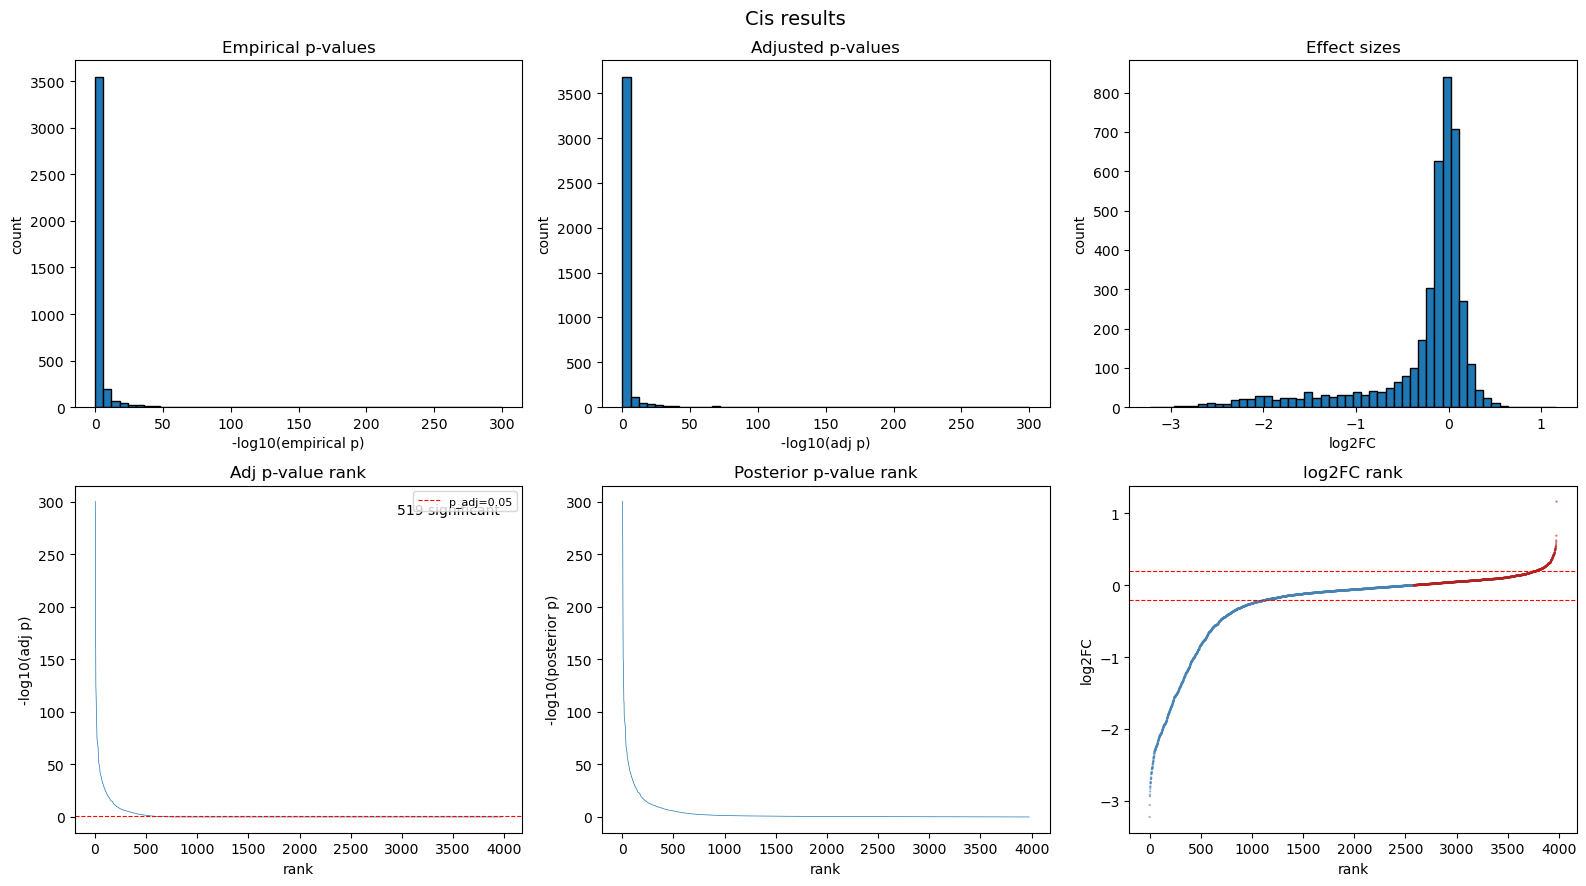

In [12]:
floor = 1e-300

# --- Cis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Cis results", fontsize=14)

cis_finite = cis[np.isfinite(cis["log2fc"])]

axes[0, 0].hist(-np.log10(cis["empirical_pval"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 0].set(xlabel="-log10(empirical p)", ylabel="count", title="Empirical p-values")

axes[0, 1].hist(-np.log10(cis["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 1].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[0, 2].hist(cis_finite["log2fc"], bins=50, edgecolor="black")
axes[0, 2].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

# Rank plots
padj_sorted = np.sort(cis["empirical_pval_adj"].values)
axes[1, 0].plot(np.arange(1, len(padj_sorted)+1), -np.log10(padj_sorted.clip(min=floor)), lw=0.5)
axes[1, 0].axhline(-np.log10(PVAL_ADJ_CUTOFF), color="r", ls="--", lw=0.8, label=f"p_adj={PVAL_ADJ_CUTOFF}")
axes[1, 0].text(0.95, 0.95, f"{(padj_sorted < PVAL_ADJ_CUTOFF).sum()} significant", transform=axes[1, 0].transAxes, ha="right", va="top")
axes[1, 0].set(xlabel="rank", ylabel="-log10(adj p)", title="Adj p-value rank")
axes[1, 0].legend(fontsize=8, loc="upper right")

post_sorted = np.sort(cis["posterior_pval"].values)
axes[1, 1].plot(np.arange(1, len(post_sorted)+1), -np.log10(post_sorted.clip(min=floor)), lw=0.5)
axes[1, 1].set(xlabel="rank", ylabel="-log10(posterior p)", title="Posterior p-value rank")

lfc_sorted = cis_finite["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[1, 2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.5, c=colors, alpha=0.5)
axes[1, 2].axhline(LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].axhline(-LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("cis_distributions.png", dpi=150)
plt.show()

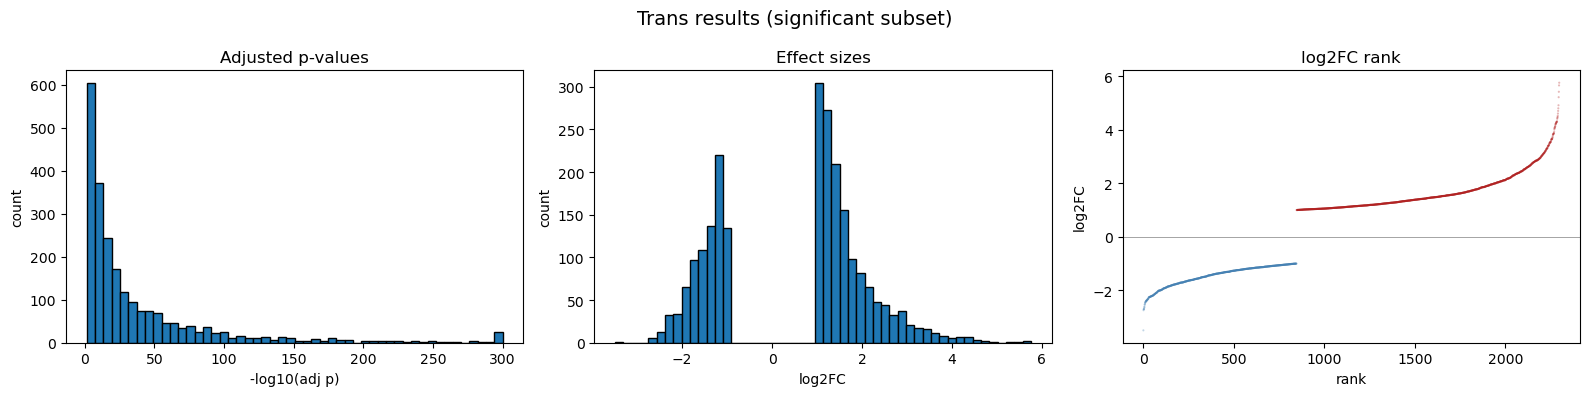

In [13]:
# --- Trans (on sig subset to avoid 22M point plots) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Trans results (significant subset)", fontsize=14)

axes[0].hist(-np.log10(trans_sig["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[1].hist(trans_sig["log2fc"], bins=50, edgecolor="black")
axes[1].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

lfc_sorted = trans_sig["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.3, c=colors, alpha=0.3)
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("trans_distributions.png", dpi=150)
plt.show()

## 8. Top trans regulators and their downstream targets

In [14]:
N_TOP_TARGETS = 5

top_trans = (
    trans_sig.groupby("element_symbol").size()
    .sort_values(ascending=False)
    .head(N_TOP_REGULATORS)
)

print("Top trans regulators:")
for symbol, count in top_trans.items():
    print(f"  {symbol}: {count} trans targets")

# Top up/down targets for leading regulators
for symbol in top_trans.index[:3]:
    subset = trans_sig[trans_sig["element_symbol"] == symbol]
    up = subset[subset["log2fc"] > 0].nlargest(N_TOP_TARGETS, "log2fc")
    down = subset[subset["log2fc"] < 0].nsmallest(N_TOP_TARGETS, "log2fc")

    print(f"\n--- {symbol}: {len(subset)} trans targets ---")
    print("  Upregulated:")
    for _, r in up.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")
    print("  Downregulated:")
    for _, r in down.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")

Top trans regulators:
  FOXH1: 705 trans targets
  SOX17: 615 trans targets
  SETDB1: 177 trans targets
  DBX1: 130 trans targets
  ZC3H3: 84 trans targets
  DNMT1: 49 trans targets
  RCOR2: 43 trans targets
  SNAI1: 33 trans targets
  HNF1B: 29 trans targets
  FOXA2: 26 trans targets
  POGK: 22 trans targets
  SMAD4: 16 trans targets
  ADNP2: 15 trans targets
  SMARCC1: 14 trans targets
  ZNF532: 12 trans targets
  ZNF90: 11 trans targets
  ZNF644: 10 trans targets
  PCGF6: 10 trans targets
  CHAMP1: 8 trans targets
  GATAD1: 8 trans targets

--- FOXH1: 705 trans targets ---
  Upregulated:
    LDB2: log2FC = 5.66
    FRMD4B: log2FC = 5.42
    FLT1: log2FC = 4.61
    COL5A2: log2FC = 4.52
    RYR2: log2FC = 4.45
  Downregulated:
    LINC02479: log2FC = -3.49
    ANKRD1: log2FC = -2.74
    ENSG00000253496: log2FC = -2.71
    GC: log2FC = -2.69
    CCL2: log2FC = -2.69

--- SOX17: 615 trans targets ---
  Upregulated:
    LRP1B: log2FC = 5.76
    NRXN1: log2FC = 4.92
    UNC13C: log2FC = 

## 9. Save filtered results

In [15]:
direct_sig.to_parquet(f"cache/direct_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
cis_sig.to_parquet(f"cache/cis_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
# trans_sig already saved in section 6

print(f"direct_sig: {len(direct_sig)} rows")
print(f"cis_sig: {len(cis_sig)} rows")
print(f"trans_sig: {len(trans_sig)} rows")

direct_sig: 472 rows
cis_sig: 518 rows
trans_sig: 2299 rows


In [75]:
trans_sig.head(2)

,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000162526,TSSK3,382,2.057008,0.294241,False,False,2.731303e-12,1.909303e-10,9.267096e-07
1,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000215866,LINC01356,382,1.027955,0.088702,False,False,4.693543e-31,4.712691e-26,6.408636e-22


In [16]:
trans_sig.describe()

,n_cells,log2fc,log2fc_se,posterior_pval,empirical_pval,empirical_pval_adj
count,2299.000000,2299.000000,2299.000000,2.299000e+03,2.299000e+03,2.299000e+03
mean,899.224880,0.533053,0.149559,1.026562e-07,7.852895e-07,1.454489e-03
std,327.927829,1.653541,0.067616,4.913652e-07,3.443610e-06,5.864604e-03
min,64.000000,-3.494927,0.026889,0.000000e+00,0.000000e+00,0.000000e+00
25%,814.000000,-1.193538,0.098343,8.186792e-63,1.957281e-52,6.070020e-48
50%,821.000000,1.131231,0.139561,5.249192e-26,7.406360e-22,8.301904e-18
75%,973.000000,1.590162,0.188465,2.173409e-13,2.319308e-11,1.240000e-07
max,2514.000000,5.759155,0.558772,5.139895e-06,3.280232e-05,4.954044e-02


In [17]:
trans_sig["element_symbol"].value_counts().head(20)

element_symbol
FOXH1      705
SOX17      615
SETDB1     177
DBX1       130
ZC3H3       84
DNMT1       49
RCOR2       43
SNAI1       33
HNF1B       29
FOXA2       26
POGK        22
SMAD4       16
ADNP2       15
SMARCC1     14
ZNF532      12
ZNF90       11
PCGF6       10
ZNF644      10
GATAD1       8
CHAMP1       8
Name: count, dtype: int64

In [18]:
tfs = pd.read_csv("~/files/TF_names_v_1.01.txt", header=None).iloc[:, 0].tolist()
len(set(trans["element_symbol"].unique().tolist()).intersection(tfs))

1579

In [19]:
# All perturbed TFs
all_tfs = guide_var[guide_var["targeting"] == True]["gene_name"].unique()
# Significant TFs (those with trans hits)
sig_tfs = trans_sig["element_symbol"].unique()
print(f"All perturbed TFs: {len(all_tfs)}")
print(f"TFs with sig trans hits: {len(sig_tfs)}")

All perturbed TFs: 2062
TFs with sig trans hits: 187


In [20]:
# All tested genes
all_genes = gene_var.index.tolist()  # Ensembl IDs
all_gene_symbols = gene_var["symbol"].unique()
# Significant target genes
sig_genes = trans_sig["tested_gene_symbol"].unique()
print(f"All tested genes: {len(all_genes)}")
print(f"Genes with sig trans hits: {len(sig_genes)}")

All tested genes: 9584
Genes with sig trans hits: 1241


---
## 10. Disease & GWAS (Working Group 3)

Goals:
1. Which TFs regulate disease/GWAS genes in this lineage
2. For TFs active in multiple lineages, is their activity convergent or divergent
3. Annotate GWAS variants near important TFs or upstream of their downstream targets

### 10a. GWAS catalog: positional overlap

In [21]:
gwas = pd.read_csv(GWAS_PATH, sep="\t", low_memory=False)
gwas = gwas[gwas["CHR_POS"].notna() & gwas["CHR_ID"].notna()].copy()
gwas["CHR_POS"] = pd.to_numeric(gwas["CHR_POS"], errors="coerce")
gwas = gwas[gwas["CHR_POS"].notna()].copy()
gwas["CHR_ID"] = gwas["CHR_ID"].astype(str)

print(f"GWAS catalog: {len(gwas)} associations, {gwas['DISEASE/TRAIT'].nunique()} traits")

GWAS catalog: 919591 associations, 41913 traits


In [22]:
# Step 1: precompute GWAS trait hits for every gene in the universe (run once)
GENE_GWAS_CACHE = f"cache/gene_gwas_all_{GWAS_WINDOW//1000}kb.parquet"

if os.path.exists(GENE_GWAS_CACHE):
    gene_gwas_all = pd.read_parquet(GENE_GWAS_CACHE)
    print(f"Loaded: {len(gene_gwas_all)} gene-trait pairs")
else:
    print("Precomputing GWAS overlap for all genes...")
    gene_coords_clean = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
    gene_coords_clean = gene_coords_clean[gene_coords_clean["gene_chr"].notna()]
    gene_coords_clean["chr_clean"] = gene_coords_clean["gene_chr"].str.replace("chr", "")

    records = []
    for i, (ens_id, gc) in enumerate(gene_coords_clean.iterrows()):
        if i % 1000 == 0:
            print(f"  {i}/{len(gene_coords_clean)}")
        nearby = gwas[
            (gwas["CHR_ID"] == gc["chr_clean"])
            & (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW)
            & (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
        ]
        for trait in nearby["DISEASE/TRAIT"].values:
            records.append({"gene_id": ens_id, "symbol": gc["symbol"], "trait": trait})

    gene_gwas_all = pd.DataFrame(records)
    gene_gwas_all.to_parquet(GENE_GWAS_CACHE, index=False)
    print(f"Saved: {len(gene_gwas_all)} gene-trait pairs")

print(f"Genes with any GWAS overlap: {gene_gwas_all['gene_id'].nunique()}")
print(f"Traits covered: {gene_gwas_all['trait'].nunique()}")

Loaded: 965472 gene-trait pairs
Genes with any GWAS overlap: 9500
Traits covered: 33242


In [23]:
# Parse element coordinates from element_id column
def parse_element_coords(df):
    parts = df["element_id"].str.extract(r"(.+)\|chr(\w+):(\d+)-(\d+)")
    df = df.copy()
    df["el_chr"] = parts[1].values
    df["el_start"] = parts[2].astype(float).values
    df["el_end"] = parts[3].astype(float).values
    return df

# Top 20 "most-perturbing" TFs
# Filter using isin()
top_trans_TFs = trans_sig["element_symbol"].value_counts().head(20).index
trans_sig_top_TFs = trans_sig[trans_sig["element_symbol"].isin(top_trans_TFs)]
print(f"Filtered: {len(trans_sig_top_TFs):,} rows")

# Top TFs only
trans_sig_coords = parse_element_coords(trans_sig_top_TFs)

# # All TFs
# trans_sig_coords = parse_element_coords(trans_sig)

# Unique element coordinates
element_coords = (
    trans_sig_coords[["element_symbol", "el_chr", "el_start", "el_end"]]
    .drop_duplicates("element_symbol")
)

# Gene coordinates from gene_var
gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")

# --- GWAS SNPs near perturbed TF elements ---
tf_gwas_hits = []
for _, el in element_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["el_chr"])
        & (gwas["CHR_POS"] >= el["el_start"] - GWAS_WINDOW)
        & (gwas["CHR_POS"] <= el["el_end"] + GWAS_WINDOW)
    ]
    for _, snp in nearby.iterrows():
        tf_gwas_hits.append({
            "tf_symbol": el["element_symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

tf_gwas = pd.DataFrame(tf_gwas_hits)
print(f"=== GWAS SNPs within {GWAS_WINDOW//1000}kb of TF elements ===")
print(f"Hits: {len(tf_gwas)}, TFs: {tf_gwas['tf_symbol'].nunique()}, Traits: {tf_gwas['trait'].nunique()}")

# --- GWAS SNPs near downstream target genes ---
target_genes = set(trans_sig["tested_gene_id"].unique())
target_coords = gene_coords[gene_coords.index.isin(target_genes)]

gene_gwas_hits = []
for ens_id, gc in target_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == gc["chr_clean"])
        & (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW)
        & (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
    ]
    for _, snp in nearby.iterrows():
        gene_gwas_hits.append({
            "gene_ensembl": ens_id,
            "gene_symbol": gc["symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

gene_gwas = pd.DataFrame(gene_gwas_hits)
print(f"\n=== GWAS SNPs within {GWAS_WINDOW//1000}kb of trans target genes ===")
print(f"Hits: {len(gene_gwas)}, Genes: {gene_gwas['gene_symbol'].nunique()}, Traits: {gene_gwas['trait'].nunique()}")

Filtered: 2,017 rows
=== GWAS SNPs within 50kb of TF elements ===
Hits: 1338, TFs: 20, Traits: 596

=== GWAS SNPs within 50kb of trans target genes ===
Hits: 144237, Genes: 1228, Traits: 16303


In [24]:
trans_sig["element_label"].value_counts()

element_label
targeting    2299
Name: count, dtype: int64

In [25]:
print(trans_sig_top_TFs.shape)
# print(trans_sig_top_TFs.head(2))

print(trans_sig.shape)
# print(trans_sig.head(2))


(2017, 13)
(2299, 13)


In [26]:
gene_gwas[["pvalue"]].describe()

,pvalue
count,1.442370e+05
mean,5.440774e-07
std,1.731087e-06
min,0.000000e+00
25%,5.000000e-20
50%,5.000000e-12
75%,1.000000e-08
max,1.000000e-05


### 10b. GWAS trait enrichment (Fisher exact test)

In [27]:
trait_counts = gwas["DISEASE/TRAIT"].value_counts()
total_snps = len(gwas)

def trait_enrichment(gwas_hits_df, label, min_hits=5):
    hit_traits = gwas_hits_df["trait"].value_counts()
    hit_traits = hit_traits[hit_traits >= min_hits]
    n_hits = len(gwas_hits_df)

    results = []
    for trait, observed in hit_traits.items():
        catalog_n = trait_counts.get(trait, 1)
        expected = catalog_n * (n_hits / total_snps)
        a = observed
        b = max(catalog_n - observed, 0)
        c = max(n_hits - observed, 0)
        d = max(total_snps - catalog_n - c, 0)
        odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        results.append({
            "trait": trait, "observed": observed, "catalog_total": catalog_n,
            "expected": round(expected, 2), "enrichment": round(observed / max(expected, 0.01), 2),
            "odds_ratio": round(odds_ratio, 2), "pvalue": pval,
        })

    edf = pd.DataFrame(results)
    edf["fdr"] = multipletests(edf["pvalue"], method="fdr_bh")[1]
    edf = edf.sort_values("fdr")
    print(f"\n=== {label}: trait enrichment (>={min_hits} hits) ===")
    print(edf.head(20).to_string(index=False))
    return edf

tf_enrichment = trait_enrichment(tf_gwas, "Near TF elements")
gene_enrichment = trait_enrichment(gene_gwas, "Near target genes")


=== Near TF elements: trait enrichment (>=5 hits) ===
                                                       trait  observed  catalog_total  expected  enrichment  odds_ratio       pvalue          fdr
                                             Prostate cancer        63           3071      4.47       14.10       15.03 9.000194e-50 4.680101e-48
                             Alanine aminotransferase levels        52           1767      2.57       20.23       21.61 4.273036e-49 1.110989e-47
                                        ICAM5 protein levels         8             77      0.11       71.41       80.04 3.787545e-13 6.565078e-12
                                Prostate cancer (late onset)        11            284      0.41       26.62       27.87 8.260910e-13 1.073918e-11
Aspartate aminotransferase to alanine aminotransferase ratio        10            217      0.32       31.67       33.40 1.619740e-12 1.684529e-11
                                             Type 2 diabetes        3

## 11. E2G (Enhancer-to-Gene) predictions

scE2G links regulatory elements to target genes using multiome data.
H7 = ESC, definitive_endoderm = DE lineage.

In [29]:
# === E2G PATHS AND THRESHOLDS ===
E2G_ESC_PATH = "data/igvf11_h7_scE2G_multiome_powerlaw_v3_threshold0.177.e2g.tsv"
E2G_DE_PATH = "data/igvf6_definitive_endoderm_scE2G_multiome_powerlaw_v3_threshold0.177.e2g.tsv"
E2G_SCORE_MIN = 0.177  # default threshold from the file, adjust as needed

In [30]:
# Load E2G predictions (skip comment lines starting with #)
e2g_esc = pd.read_csv(E2G_ESC_PATH, sep="\t", comment="#")
e2g_de = pd.read_csv(E2G_DE_PATH, sep="\t", comment="#")

e2g_esc["source"] = "ESC"
e2g_de["source"] = "DE"

print(f"ESC (H7): {len(e2g_esc)} E2G links, {e2g_esc['GeneSymbol'].nunique()} genes, {e2g_esc['ElementName'].nunique()} elements")
print(f"DE: {len(e2g_de)} E2G links, {e2g_de['GeneSymbol'].nunique()} genes, {e2g_de['ElementName'].nunique()} elements")

ESC (H7): 62325 E2G links, 12390 genes, 48748 elements
DE: 60889 E2G links, 12667 genes, 47642 elements


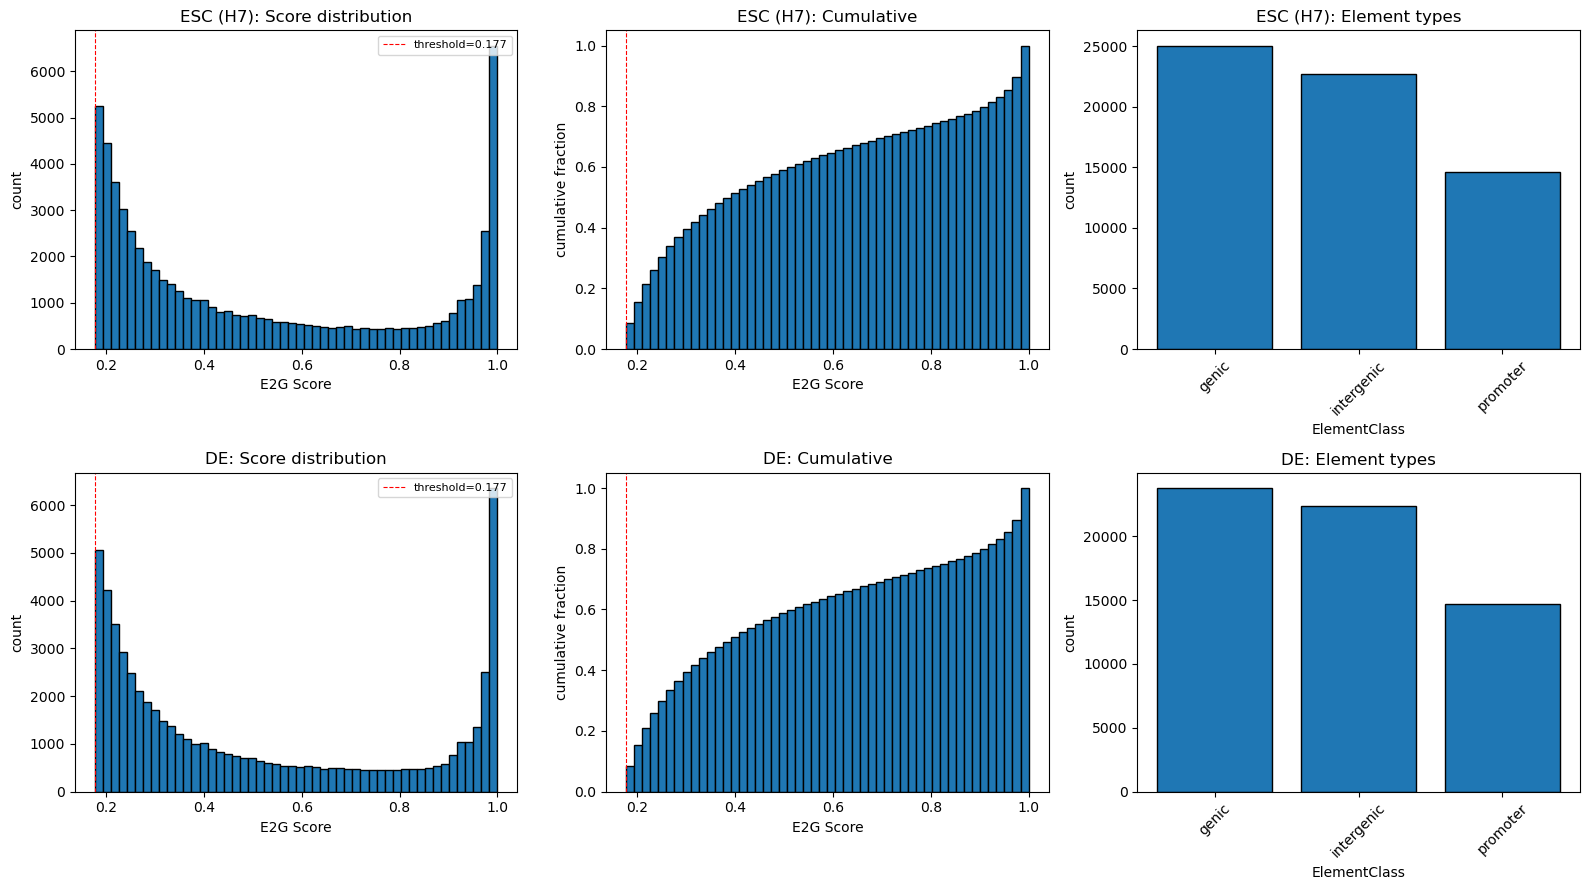


ESC element classes:
ElementClass
genic         25044
intergenic    22696
promoter      14585

DE element classes:
ElementClass
genic         23802
intergenic    22403
promoter      14684

ESC isSelfPromoter: isSelfPromoter
False    47740
True     14585
DE isSelfPromoter: isSelfPromoter
False    46205
True     14684


In [31]:
# === E2G score distributions ===
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (e2g, label) in enumerate([(e2g_esc, "ESC (H7)"), (e2g_de, "DE")]):
    axes[row, 0].hist(e2g["Score"], bins=50, edgecolor="black")
    axes[row, 0].axvline(E2G_SCORE_MIN, color="r", ls="--", lw=0.8, label=f"threshold={E2G_SCORE_MIN}")
    axes[row, 0].set(xlabel="E2G Score", ylabel="count", title=f"{label}: Score distribution")
    axes[row, 0].legend(fontsize=8, loc="upper right")

    axes[row, 1].hist(e2g["Score"], bins=50, edgecolor="black", cumulative=True, density=True)
    axes[row, 1].axvline(E2G_SCORE_MIN, color="r", ls="--", lw=0.8)
    axes[row, 1].set(xlabel="E2G Score", ylabel="cumulative fraction", title=f"{label}: Cumulative")

    class_counts = e2g["ElementClass"].value_counts()
    axes[row, 2].bar(class_counts.index, class_counts.values, edgecolor="black")
    axes[row, 2].set(xlabel="ElementClass", ylabel="count", title=f"{label}: Element types")
    axes[row, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("e2g_distributions.png", dpi=150)
plt.show()

print(f"\nESC element classes:\n{e2g_esc['ElementClass'].value_counts().to_string()}")
print(f"\nDE element classes:\n{e2g_de['ElementClass'].value_counts().to_string()}")
print(f"\nESC isSelfPromoter: {e2g_esc['isSelfPromoter'].value_counts().to_string()}")
print(f"DE isSelfPromoter: {e2g_de['isSelfPromoter'].value_counts().to_string()}")

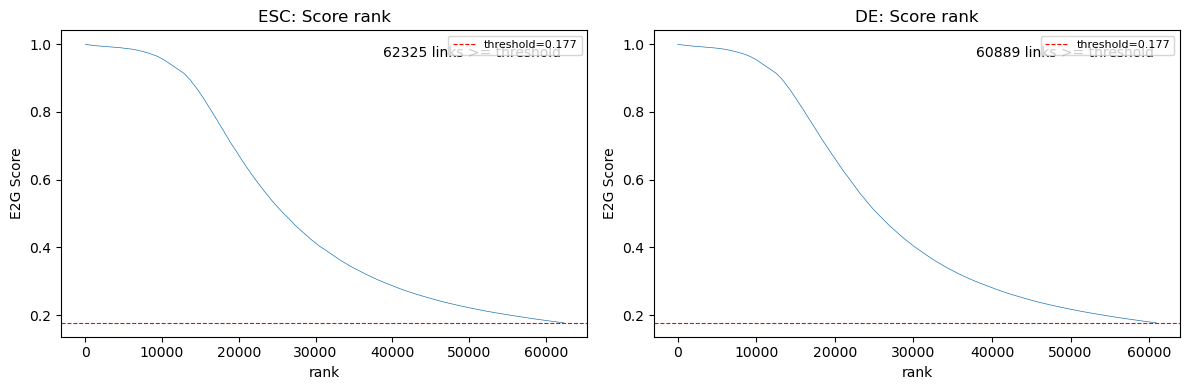

In [32]:
# === Score rank plots ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (e2g, label) in zip(axes, [(e2g_esc, "ESC"), (e2g_de, "DE")]):
    scores_sorted = e2g["Score"].sort_values(ascending=False).values
    ax.plot(np.arange(len(scores_sorted)), scores_sorted, lw=0.5)
    ax.axhline(E2G_SCORE_MIN, color="r", ls="--", lw=0.8, label=f"threshold={E2G_SCORE_MIN}")
    n_above = (scores_sorted >= E2G_SCORE_MIN).sum()
    ax.text(0.95, 0.95, f"{n_above} links >= threshold", transform=ax.transAxes, ha="right", va="top")
    ax.set(xlabel="rank", ylabel="E2G Score", title=f"{label}: Score rank")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("e2g_score_ranks.png", dpi=150)
plt.show()

In [33]:
# === Filter E2G by score and combine ===
e2g_esc_filt = e2g_esc[e2g_esc["Score"] >= E2G_SCORE_MIN].copy()
e2g_de_filt = e2g_de[e2g_de["Score"] >= E2G_SCORE_MIN].copy()
e2g_combined = pd.concat([e2g_esc_filt, e2g_de_filt], ignore_index=True)

print(f"ESC after filter: {len(e2g_esc_filt)} links, {e2g_esc_filt['GeneSymbol'].nunique()} genes")
print(f"DE after filter: {len(e2g_de_filt)} links, {e2g_de_filt['GeneSymbol'].nunique()} genes")
print(f"Combined: {len(e2g_combined)} links, {e2g_combined['GeneSymbol'].nunique()} unique genes")

# Genes shared between ESC and DE
shared_genes = set(e2g_esc_filt["GeneSymbol"]) & set(e2g_de_filt["GeneSymbol"])
print(f"Genes in both ESC and DE: {len(shared_genes)}")

ESC after filter: 62325 links, 12390 genes
DE after filter: 60889 links, 12667 genes
Combined: 123214 links, 13635 unique genes
Genes in both ESC and DE: 11422


In [34]:
# === Intersect E2G genes with trans_sig ===
e2g_genes = set(e2g_combined["GeneSymbol"].unique())

# Which E2G genes are perturbed TFs in trans_sig?
trans_tfs = set(trans_sig["element_symbol"].unique())
# Which E2G genes are trans target genes?
trans_targets = set(trans_sig["tested_gene_symbol"].unique())

tf_in_e2g = trans_tfs & e2g_genes
target_in_e2g = trans_targets & e2g_genes

print(f"E2G genes that are perturbed TFs: {len(tf_in_e2g)} / {len(trans_tfs)}")
print(f"E2G genes that are trans targets: {len(target_in_e2g)} / {len(trans_targets)}")

# Build intersection table
# For TFs: merge trans_sig rows where element_symbol is in E2G
trans_tf_e2g = trans_sig[trans_sig["element_symbol"].isin(tf_in_e2g)].copy()
trans_tf_e2g["e2g_match"] = "perturbed_TF"

# For target genes: merge trans_sig rows where tested_gene_symbol is in E2G
trans_target_e2g = trans_sig[trans_sig["tested_gene_symbol"].isin(target_in_e2g)].copy()
trans_target_e2g["e2g_match"] = "target_gene"

# Combine (some rows may appear in both if TF is also a target of another TF)
trans_sig_e2g = pd.concat([trans_tf_e2g, trans_target_e2g], ignore_index=True).drop_duplicates(
    subset=["element_id", "tested_gene_id", "e2g_match"]
)

print(f"\nTrans_sig rows with E2G overlap: {len(trans_sig_e2g)}")
print(f"  via perturbed TF: {(trans_sig_e2g['e2g_match'] == 'perturbed_TF').sum()}")
print(f"  via target gene: {(trans_sig_e2g['e2g_match'] == 'target_gene').sum()}")
print(f"  unique TFs: {trans_sig_e2g[trans_sig_e2g['e2g_match'] == 'perturbed_TF']['element_symbol'].nunique()}")
print(f"  unique target genes: {trans_sig_e2g[trans_sig_e2g['e2g_match'] == 'target_gene']['tested_gene_symbol'].nunique()}")

# Add E2G source info (ESC, DE, or both)
gene_source = (
    e2g_combined.groupby("GeneSymbol")["source"]
    .apply(lambda x: ",".join(sorted(x.unique())))
    .to_dict()
)

trans_sig_e2g["e2g_source"] = trans_sig_e2g.apply(
    lambda r: gene_source.get(
        r["element_symbol"] if r["e2g_match"] == "perturbed_TF" else r["tested_gene_symbol"], ""
    ), axis=1
)

print(f"\nE2G source breakdown:")
print(trans_sig_e2g["e2g_source"].value_counts().to_string())

trans_sig_e2g.to_parquet(
    f"cache/trans_sig_e2g_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_TRANS_MIN}_e2g{E2G_SCORE_MIN}.parquet",
    index=False
)

E2G genes that are perturbed TFs: 167 / 187
E2G genes that are trans targets: 890 / 1241

Trans_sig rows with E2G overlap: 3681
  via perturbed TF: 2133
  via target gene: 1548
  unique TFs: 167
  unique target genes: 890

E2G source breakdown:
e2g_source
DE,ESC    2835
DE         784
ESC         62


In [35]:
# === Intersect E2G elements with GWAS SNPs ===
# Use the E2G element coordinates (ElementChr, ElementStart, ElementEnd) for positional overlap

# Get E2G elements linked to genes in trans_sig_e2g
e2g_genes_in_trans = set()
e2g_genes_in_trans.update(
    trans_sig_e2g[trans_sig_e2g["e2g_match"] == "perturbed_TF"]["element_symbol"]
)
e2g_genes_in_trans.update(
    trans_sig_e2g[trans_sig_e2g["e2g_match"] == "target_gene"]["tested_gene_symbol"]
)

e2g_elements_for_gwas = e2g_combined[
    e2g_combined["GeneSymbol"].isin(e2g_genes_in_trans)
][["ElementChr", "ElementStart", "ElementEnd", "ElementName", "GeneSymbol", "Score", "source"]].drop_duplicates()

e2g_elements_for_gwas["chr_clean"] = e2g_elements_for_gwas["ElementChr"].str.replace("chr", "")

print(f"E2G elements to intersect with GWAS: {len(e2g_elements_for_gwas)}")
print(f"Linked to {e2g_elements_for_gwas['GeneSymbol'].nunique()} genes")

E2G elements to intersect with GWAS: 13818
Linked to 1041 genes


In [36]:
# Positional overlap: GWAS SNPs within E2G elements (no window, direct overlap)
e2g_gwas_hits = []
for _, el in e2g_elements_for_gwas.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["chr_clean"])
        & (gwas["CHR_POS"] >= el["ElementStart"])
        & (gwas["CHR_POS"] <= el["ElementEnd"])
    ]
    for _, snp in nearby.iterrows():
        e2g_gwas_hits.append({
            "element_name": el["ElementName"],
            "element_chr": el["ElementChr"],
            "element_start": el["ElementStart"],
            "element_end": el["ElementEnd"],
            "e2g_gene": el["GeneSymbol"],
            "e2g_score": el["Score"],
            "e2g_source": el["source"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "gwas_pvalue": snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

e2g_gwas = pd.DataFrame(e2g_gwas_hits)
print(f"E2G element x GWAS SNP overlaps: {len(e2g_gwas)}")
print(f"Unique E2G elements with SNPs: {e2g_gwas['element_name'].nunique()}")
print(f"Unique genes: {e2g_gwas['e2g_gene'].nunique()}")
print(f"Unique traits: {e2g_gwas['trait'].nunique()}")

if len(e2g_gwas) > 0:
    print(f"\nTop traits in E2G elements:")
    print(e2g_gwas["trait"].value_counts().head(15).to_string())

    print(f"\nTop genes with GWAS SNPs in their E2G elements:")
    print(e2g_gwas.groupby("e2g_gene")["trait"].nunique().sort_values(ascending=False).head(15).to_string())

    e2g_gwas.to_parquet(
        f"cache/e2g_gwas_overlaps_e2g{E2G_SCORE_MIN}.parquet",
        index=False
    )

E2G element x GWAS SNP overlaps: 12331
Unique E2G elements with SNPs: 2260
Unique genes: 638
Unique traits: 2614

Top traits in E2G elements:
trait
Height                                        368
Body mass index                               127
Systolic blood pressure                       108
Type 2 diabetes                               103
Diastolic blood pressure                      101
Triglyceride levels                            96
Total cholesterol levels                       95
Sex hormone-binding globulin levels            88
Platelet count                                 85
Height (baseline)                              82
Monounsaturated fatty acid levels              78
Prostate cancer                                76
Waist-to-hip ratio adjusted for BMI            68
Low density lipoprotein cholesterol levels     66
Total fatty acid levels                        63

Top genes with GWAS SNPs in their E2G elements:
e2g_gene
APOC1      382
MYOF       326
ARID1A     216

In [55]:
# e2g_gwas[e2g_gwas["e2g_gene"] == "ZIC3"]
# e2g_gwas[e2g_gwas["trait"].str.contains("cancer", case=False, na=False)]
# e2g_gwas[e2g_gwas["e2g_gene"].con]
e2g_gwas.head(10)

,element_name,element_chr,element_start,element_end,e2g_gene,e2g_score,e2g_source,snp,trait,gwas_pvalue,mapped_gene
0,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,HDL cholesterol levels,1.000000e-10,HES4
1,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,HDL cholesterol,2.000000e-11,HES4
2,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,Drinks per week,1.000000e-13,HES4
3,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,Drinks per week,8.000000e-13,HES4
4,chr1:999909-1001072,chr1,999909,1001072,HES4,0.981925,ESC,rs3121569,Alanine levels,5.000000e-13,HES4 - ISG15
5,chr1:1013172-1014171,chr1,1013172,1014171,ISG15,0.995194,ESC,rs4615788,Ubiquitin-like protein ISG15 levels,1.000000e-85,ISG15
6,chr1:1013172-1014171,chr1,1013172,1014171,ISG15,0.995194,ESC,rs4615788,Ubiquitin-like protein ISG15 levels,6.000000e-109,ISG15
7,chr1:1013172-1014171,chr1,1013172,1014171,ISG15,0.995194,ESC,rs4615788,Ubiquitin-like protein ISG15 levels,1.000000e-277,ISG15
8,chr1:1024572-1025536,chr1,1024572,1025536,HES4,0.185530,ESC,rs4970392,Total cholesterol levels,3.000000e-08,AGRN
9,chr1:1024572-1025536,chr1,1024572,1025536,ISG15,0.602656,ESC,rs4970392,Total cholesterol levels,3.000000e-08,AGRN


In [57]:
print(f"Total overlaps: {len(e2g_gwas)}")
print(f"Unique E2G elements: {e2g_gwas['element_name'].nunique()}")
print(f"Unique genes: {e2g_gwas['e2g_gene'].nunique()}")
print(f"Unique SNPs: {e2g_gwas['snp'].nunique()}")
print(f"Unique traits: {e2g_gwas['trait'].nunique()}")
print(f"\nSource breakdown:\n{e2g_gwas['e2g_source'].value_counts()}")

# Are E2G-predicted genes the same as GWAS mapped genes?
e2g_gwas["gene_matches_gwas"] = e2g_gwas["e2g_gene"] == e2g_gwas["mapped_gene"]
print(f"\nE2G gene matches GWAS mapped gene: {e2g_gwas['gene_matches_gwas'].mean():.1%}")

# Cases where E2G links a variant to a DIFFERENT gene than GWAS proximity
novel_links = e2g_gwas[~e2g_gwas["gene_matches_gwas"]]
print(f"Novel E2G gene assignments (not nearest gene): {len(novel_links)}")
print(f"Unique novel genes: {novel_links['e2g_gene'].nunique()}")

# Top genes by number of GWAS trait associations
print("\nGenes with most GWAS trait associations via E2G:")
print(
    e2g_gwas.groupby("e2g_gene")["trait"].nunique()
    .sort_values(ascending=False)
    .head(20)
    .to_string()
)

# Top traits
print("\nTop traits:")
print(e2g_gwas["trait"].value_counts().head(20).to_string())

# High-confidence hits: high E2G score + significant GWAS p-value
strong = e2g_gwas[(e2g_gwas["e2g_score"] > 0.5) & (e2g_gwas["gwas_pvalue"] < 5e-8)]
print(f"\nStrong hits (E2G>0.5, GWAS p<5e-8): {len(strong)}")
print(f"Unique genes: {strong['e2g_gene'].nunique()}")
print(f"Unique traits: {strong['trait'].nunique()}")

# ESC vs DE specific hits
print("\nESC-only genes:")
esc_genes = set(e2g_gwas[e2g_gwas["e2g_source"] == "ESC"]["e2g_gene"])
de_genes = set(e2g_gwas[e2g_gwas["e2g_source"] == "DE"]["e2g_gene"])
print(f"  ESC only: {len(esc_genes - de_genes)}")
print(f"  DE only: {len(de_genes - esc_genes)}")
print(f"  Both: {len(esc_genes & de_genes)}")

Total overlaps: 12331
Unique E2G elements: 2260
Unique genes: 638
Unique SNPs: 2205
Unique traits: 2614

Source breakdown:
e2g_source
DE     6325
ESC    6006
Name: count, dtype: int64

E2G gene matches GWAS mapped gene: 41.5%
Novel E2G gene assignments (not nearest gene): 7215
Unique novel genes: 464

Genes with most GWAS trait associations via E2G:
e2g_gene
APOC1      382
MYOF       326
ARID1A     216
HLA-B      207
APOE       183
TAGLN      148
HLA-C      137
KIRREL3     95
ANXA2       82
CCNQ        75
HLA-A       66
GMPR        62
MN1         60
JADE2       59
HMGA1       58
VEGFA       55
TRABD2B     52
SLC22A3     47
MYL7        47
PROX1       42

Top traits:
trait
Height                                                         368
Body mass index                                                127
Systolic blood pressure                                        108
Type 2 diabetes                                                103
Diastolic blood pressure                            

In [68]:
import pyBigWig
import os

# === CONFIG ===
BW_DIR = "../NG_paper_Danwei/"
SIGNAL_FRAC_OF_MAX = 0.10
# SNP_WINDOW = 300  # uncomment later

# === Get exact SNP positions from GWAS catalog ===
snp_positions = (
    gwas[["SNPS", "CHR_ID", "CHR_POS"]]
    .dropna(subset=["CHR_ID", "CHR_POS"])
    .copy()
)
snp_positions["CHR_POS"] = pd.to_numeric(snp_positions["CHR_POS"], errors="coerce")
snp_positions = snp_positions.dropna(subset=["CHR_POS"])
snp_positions["CHR_POS"] = snp_positions["CHR_POS"].astype(int)
snp_positions["chrom"] = "chr" + snp_positions["CHR_ID"].astype(str)
snp_positions = snp_positions[["SNPS", "chrom", "CHR_POS"]].drop_duplicates(subset=["chrom", "CHR_POS"])

# Merge to get coordinates for e2g_gwas SNPs
e2g_gwas_pos = e2g_gwas.merge(
    snp_positions.rename(columns={"SNPS": "snp"}),
    on="snp", how="left"
)

# Deduplicate on coordinates
unique_loci = (
    e2g_gwas_pos[["chrom", "CHR_POS"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
unique_loci["CHR_POS"] = unique_loci["CHR_POS"].astype(int)

print(f"Unique genomic positions to query: {len(unique_loci)}")
print(f"(deduplicated from {len(e2g_gwas)} rows)")

# === List bigwig files ===
# bw_files = sorted([f for f in os.listdir(BW_DIR) if f.endswith(".bigwig")])
bw_files = sorted([f for f in os.listdir(BW_DIR) if f.endswith(".bigwig") and \
    f.startswith("GSE") and \
        "ATAC" not in f.upper() and \
            "H3K" not in f.upper()])
print(f"\nBigwig files: {len(bw_files)}")
for f in bw_files:
    print(f"  {f}")

# === Query each bigwig at unique positions ===
results = unique_loci.copy()

for bw_file in bw_files:
    bw_path = os.path.join(BW_DIR, bw_file)
    bw = pyBigWig.open(bw_path)
    bw_max = bw.header()["maxVal"]
    threshold = bw_max * SIGNAL_FRAC_OF_MAX
    label = bw_file.replace("GSE213394_", "").replace("_hg38.bigwig", "")

    signals = []
    for _, row in unique_loci.iterrows():
        try:
            val = bw.values(row["chrom"], row["CHR_POS"], row["CHR_POS"] + 1)[0]
        except:
            val = 0.0
        signals.append(val if val is not None else 0.0)

    results[f"{label}_signal"] = signals
    results[f"{label}_pass"] = [s >= threshold for s in signals]

    n_pass = sum(results[f"{label}_pass"])
    print(f"  {label}: max={bw_max:.3f}, thresh={threshold:.3f}, passing={n_pass}/{len(unique_loci)}")
    bw.close()

# === Summary ===
pass_cols = [c for c in results.columns if c.endswith("_pass")]
results["n_chipseq_passing"] = results[pass_cols].sum(axis=1)

print(f"\nPositions with signal in >=1 ChIP: {(results['n_chipseq_passing'] > 0).sum()}")
print(f"Positions with signal in 0 ChIPs: {(results['n_chipseq_passing'] == 0).sum()}")

# === Merge back ===
e2g_gwas_chip = e2g_gwas_pos.merge(results, on=["chrom", "CHR_POS"], how="left")

print(f"\nFinal table: {e2g_gwas_chip.shape}")
e2g_gwas_chip.to_parquet(
    f"cache/e2g_gwas_chipseq_frac{SIGNAL_FRAC_OF_MAX}.parquet",
    index=False
)

e2g_gwas_chip_filtered = e2g_gwas_chip[e2g_gwas_chip["n_chipseq_passing"] > 0].copy()
print(f"Rows with ChIP support: {len(e2g_gwas_chip_filtered)} / {len(e2g_gwas_chip)}")

e2g_gwas_chip_filtered.to_parquet(
    f"cache/e2g_gwas_chipseq_filtered_frac{SIGNAL_FRAC_OF_MAX}.parquet",
    index=False
)

Unique genomic positions to query: 2197
(deduplicated from 12331 rows)

Bigwig files: 5
  GSE213394_DED2-CTCF_hg38.bigwig
  GSE213394_DED2-EOMES_hg38.bigwig
  GSE213394_DED2-GATA6_hg38.bigwig
  GSE213394_DED2-SOX17_hg38.bigwig
  GSE213394_ESC-CTCF_hg38.bigwig
  DED2-CTCF: max=4.000, thresh=0.400, passing=626/2197
  DED2-EOMES: max=2.000, thresh=0.200, passing=1442/2197
  DED2-GATA6: max=19.000, thresh=1.900, passing=44/2197
  DED2-SOX17: max=10.000, thresh=1.000, passing=88/2197
  ESC-CTCF: max=3.000, thresh=0.300, passing=713/2197

Positions with signal in >=1 ChIP: 1601
Positions with signal in 0 ChIPs: 596

Final table: (12331, 25)
Rows with ChIP support: 10275 / 12331


In [75]:
e2g_gwas_chip_filtered

,element_name,element_chr,element_start,element_end,e2g_gene,e2g_score,e2g_source,snp,trait,gwas_pvalue,...,DED2-CTCF_pass,DED2-EOMES_signal,DED2-EOMES_pass,DED2-GATA6_signal,DED2-GATA6_pass,DED2-SOX17_signal,DED2-SOX17_pass,ESC-CTCF_signal,ESC-CTCF_pass,n_chipseq_passing
0,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,HDL cholesterol levels,1.000000e-10,...,False,0.37510,True,0.00000,False,0.30317,False,0.29821,False,1.0
1,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,HDL cholesterol,2.000000e-11,...,False,0.37510,True,0.00000,False,0.30317,False,0.29821,False,1.0
2,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,Drinks per week,1.000000e-13,...,False,0.37510,True,0.00000,False,0.30317,False,0.29821,False,1.0
3,chr1:998440-999843,chr1,998440,999843,HES4,0.995318,ESC,rs2298214,Drinks per week,8.000000e-13,...,False,0.37510,True,0.00000,False,0.30317,False,0.29821,False,1.0
4,chr1:999909-1001072,chr1,999909,1001072,HES4,0.981925,ESC,rs3121569,Alanine levels,5.000000e-13,...,True,0.62036,True,0.25980,False,0.71658,False,0.38478,True,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12326,chrX:137565451-137566702,chrX,137565451,137566702,ZIC3,0.986817,DE,rs12843772,aparc-pial lh area rostralmiddlefrontal,2.000000e-11,...,True,0.50494,True,0.36372,False,0.52366,False,0.50984,True,3.0
12327,chrX:137565451-137566702,chrX,137565451,137566702,ZIC3,0.986817,DE,rs12843772,aparc-DKTatlas lh area rostralmiddlefrontal,5.000000e-12,...,True,0.50494,True,0.36372,False,0.52366,False,0.50984,True,3.0
12328,chrX:137565451-137566702,chrX,137565451,137566702,ZIC3,0.986817,DE,rs12843772,Surface area (left rostral middle frontal),4.000000e-18,...,True,0.50494,True,0.36372,False,0.52366,False,0.50984,True,3.0
12329,chrX:137565451-137566702,chrX,137565451,137566702,ZIC3,0.986817,DE,rs12843772,Surface area (right rostral middle frontal),5.000000e-10,...,True,0.50494,True,0.36372,False,0.52366,False,0.50984,True,3.0


In [73]:
signal_cols = [c for c in e2g_gwas_chip.columns if c.endswith("_signal")]
pass_cols = [c for c in e2g_gwas_chip.columns if c.endswith("_pass")]

chip_hits = e2g_gwas_chip[e2g_gwas_chip["n_chipseq_passing"] > 0].copy()

# Add e2g_match if not already present (from the band-aid fix earlier)
if "e2g_match" not in chip_hits.columns:
    gene_to_match = (
        trans_sig_e2g.apply(
            lambda r: r["element_symbol"] if r["e2g_match"] == "perturbed_TF" else r["tested_gene_symbol"],
            axis=1
        ).groupby(trans_sig_e2g["e2g_match"]).groups  # not needed, use the dict approach
    )
    # Simpler: build the lookup
    match_records = trans_sig_e2g[["element_symbol", "tested_gene_symbol", "e2g_match"]].copy()
    match_records["matched_gene"] = match_records.apply(
        lambda r: r["element_symbol"] if r["e2g_match"] == "perturbed_TF" else r["tested_gene_symbol"],
        axis=1
    )
    gene_match_map = (
        match_records.groupby("matched_gene")["e2g_match"]
        .apply(lambda x: ",".join(sorted(x.unique())))
        .to_dict()
    )
    chip_hits["e2g_match"] = chip_hits["e2g_gene"].map(gene_match_map)

# Also add the perturbed TF and target gene from trans_sig_e2g
# For each e2g_gene, find which TFs perturb it or which TFs it's a target of
gene_to_tf = (
    trans_sig_e2g[trans_sig_e2g["e2g_match"] == "target_gene"]
    .groupby("tested_gene_symbol")["element_symbol"]
    .apply(lambda x: ",".join(sorted(x.unique())))
    .to_dict()
)
gene_to_target = (
    trans_sig_e2g[trans_sig_e2g["e2g_match"] == "perturbed_TF"]
    .groupby("element_symbol")["tested_gene_symbol"]
    .apply(lambda x: ",".join(sorted(x.unique()[:5])))  # limit to 5 for display
    .to_dict()
)

chip_hits["perturbed_by_TF"] = chip_hits["e2g_gene"].map(gene_to_tf).fillna("")
chip_hits["targets_of_TF"] = chip_hits["e2g_gene"].map(gene_to_target).fillna("")

display_cols = [
    "e2g_gene", "e2g_match", "perturbed_by_TF", "targets_of_TF",
    "element_name", "e2g_score", "e2g_source",
    "snp", "trait"
]

for sig_col in signal_cols:
    label = sig_col.replace("_signal", "")
    pass_col = f"{label}_pass"
    subset = chip_hits[chip_hits[pass_col] == True].copy()

    if len(subset) == 0:
        print(f"\n=== {label}: no hits ===")
        continue

    print(f"\n=== {label}: {len(subset)} hits, {subset['e2g_gene'].nunique()} genes ===")
    top = (
        subset.sort_values(sig_col, ascending=False)
        .drop_duplicates(subset=["e2g_gene", "snp"])
        .head(10)[display_cols + [sig_col]]
    )
    print(top.to_string(index=False))


=== DED2-CTCF: 4000 hits, 340 genes ===
e2g_gene   e2g_match        perturbed_by_TF targets_of_TF              element_name  e2g_score e2g_source         snp                                                                 trait  DED2-CTCF_signal
    ENO2 target_gene                  SNAI1                   chr12:6944461-6944961   0.231765         DE    rs744167                                                 CLSTN3 protein levels           4.32420
   KRT18 target_gene      FOXH1,SOX17,ZNF48                 chr12:53046520-53048138   0.178347        ESC rs540859660                                               Systolic blood pressure           4.24348
    KRT8 target_gene DBX1,FOXH1,SOX17,ZNF48                 chr12:53046520-53048138   0.381491        ESC rs540859660                                               Systolic blood pressure           4.24348
  IGFBP6 target_gene                  SOX17                 chr12:53046520-53048138   0.493758        ESC rs540859660                  